# RQ2 – GEG vs EG (Exponentiated Gradient): Fairness, Performance, and Trade-off

**Research Question 2**: Does GEG achieve comparable or better fairness–performance trade-offs compared to EG (Exponentiated Gradient)?

- **Datasets**: adult, compas, german  
- **GEG constraints**: `cp`, `dp`, `eo`  
- **EG constraints**: `dp`, `eo`  
- **Baseline**: logistic regression (no debiasing, `lr`)  
- **Fairness metrics**: Statistical Parity (SP), Equal Opportunity (EO), Average Odds (AO) – absolute values  
- **Performance metrics**: Accuracy, Precision, Recall, F1-score

## 1. Importazione delle Librerie

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

EXPERIMENTS = Path(".")  # notebook lives inside experiments/
IMGS = EXPERIMENTS / "imgs"
IMGS.mkdir(exist_ok=True)

DATASETS    = ["adult", "compas", "german"]
# EG files do not have wc_* columns – use standard fairness metrics
FAIRNESS_METRICS   = ["statistical_parity", "equal_opportunity", "average_odds"]
PERFORMANCE_METRICS = ["accuracy", "precision", "recall", "f1_score"]
METHODS_ORDER = ["Baseline", "GEG-CP", "EG-DP", "EG-EO"]
PALETTE = {
    "Baseline": "#4C72B0",
    "GEG-CP":   "#DD8452",
    "GEG-DP":   "#55A868",
    "GEG-EO":   "#C44E52",
    "EG-DP":    "#8172B2",
    "EG-EO":    "#937860",
}
METRIC_LABELS = {
    "statistical_parity": "Statistical Parity",
    "equal_opportunity":  "Equal Opportunity",
    "average_odds":       "Average Odds",
    "accuracy":           "Accuracy",
    "precision":          "Precision",
    "recall":             "Recall",
    "f1_score":           "F1-score",
}
print("Libraries loaded.")

Libraries loaded.


## 2. Caricamento e Preparazione dei Dati

In [6]:
def load_baseline_rq2(datasets=DATASETS):
    dfs = []
    for ds in datasets:
        f = EXPERIMENTS / "results_baseline_rq2" / f"{ds}_baseline_results.csv"
        df = pd.read_csv(f)
        df["dataset"] = ds
        df["method"] = "Baseline"
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def load_geg_rq2(datasets=DATASETS, constraints=("cp", "dp", "eo")):
    dfs = []
    for ds in datasets:
        for c in constraints:
            f = EXPERIMENTS / "results_geg_rq2" / f"{ds}_geg_{c}_results.csv"
            df = pd.read_csv(f)
            df["dataset"] = ds
            df["method"] = f"GEG-{c.upper()}"
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def load_eg_rq2(datasets=DATASETS):
    """EG results: single file per dataset containing both eg_dp and eg_eo rows."""
    dfs = []
    for ds in datasets:
        f = EXPERIMENTS / "results_eg" / f"{ds}_results.csv"
        df = pd.read_csv(f)
        df["dataset"] = ds
        # Map constraint column to method label
        df["method"] = df["constraint"].map({"eg_dp": "EG-DP", "eg_eo": "EG-EO"})
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


baseline = load_baseline_rq2()
geg      = load_geg_rq2(constraints=["cp"])
eg       = load_eg_rq2()
df_all   = pd.concat([baseline, geg, eg], ignore_index=True)

# Absolute values for fairness metrics
for m in FAIRNESS_METRICS:
    df_all[m] = df_all[m].abs()

print(f"Loaded {len(df_all)} rows | methods: {sorted(df_all['method'].unique())}")
df_all.head()

Loaded 120 rows | methods: ['Baseline', 'EG-DP', 'EG-EO', 'GEG-CP']


,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,dataset,method
0,1,0.8339,0.7830,0.7329,0.7520,0.1577,0.0501,0.0581,-0.1577,0.0661,0.0581,lr,adult,Baseline
1,2,0.8342,0.7865,0.7498,0.7648,0.2102,0.1906,0.1440,-0.2102,-0.1906,-0.1440,lr,adult,Baseline
2,3,0.8387,0.7843,0.7452,0.7612,0.1819,0.2150,0.1447,-0.1819,-0.2150,0.1447,lr,adult,Baseline
3,4,0.8449,0.7987,0.7562,0.7733,0.1907,0.1922,0.1355,-0.1907,-0.1922,-0.1355,lr,adult,Baseline
4,5,0.8306,0.7688,0.7388,0.7515,0.1725,0.0833,0.0872,-0.1725,0.0912,0.0872,lr,adult,Baseline


## 3. Analisi delle Metriche di Fairness

$$\Delta_{SP} = |P(\hat{Y}=1 \mid A=0) - P(\hat{Y}=1 \mid A=1)|$$

$$\Delta_{EO} = |TPR_{A=0} - TPR_{A=1}|$$

$$\Delta_{AO} = \frac{1}{2}(|FPR_{A=0} - FPR_{A=1}| + |TPR_{A=0} - TPR_{A=1}|)$$

Valori più bassi indicano maggiore fairness.

In [7]:
fairness_summary = (
    df_all.groupby(["dataset", "method"])[FAIRNESS_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)
fairness_summary.columns = ["_".join(c).strip("_") for c in fairness_summary.columns]
fairness_summary["method"] = pd.Categorical(
    fairness_summary["method"], categories=METHODS_ORDER, ordered=True
)
fairness_summary = fairness_summary.sort_values(["dataset", "method"])
fairness_summary.head(18)

,dataset,method,statistical_parity_mean,statistical_parity_std,equal_opportunity_mean,equal_opportunity_std,average_odds_mean,average_odds_std
0,adult,Baseline,0.1855,0.0155,0.1402,0.0684,0.1125,0.0341
3,adult,GEG-CP,0.0774,0.0366,0.1189,0.0944,0.0593,0.0531
1,adult,EG-DP,0.0178,0.0148,0.2694,0.0685,0.1503,0.0372
2,adult,EG-EO,0.0945,0.0100,0.0419,0.0384,0.0211,0.0171
4,compas,Baseline,0.1740,0.0402,0.1021,0.0308,0.1499,0.0416
7,compas,GEG-CP,0.0628,0.0524,0.0376,0.0252,0.0550,0.0397
5,compas,EG-DP,0.0408,0.0287,0.0611,0.0466,0.0364,0.0309
6,compas,EG-EO,0.0468,0.0423,0.0315,0.0226,0.0458,0.0237
8,german,Baseline,0.2119,0.1261,0.1813,0.1612,0.1727,0.1437
11,german,GEG-CP,0.1554,0.0929,0.1160,0.1473,0.1709,0.0882


## 4. Analisi delle Metriche di Performance

In [8]:
perf_summary = (
    df_all.groupby(["dataset", "method"])[PERFORMANCE_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)
perf_summary.columns = ["_".join(c).strip("_") for c in perf_summary.columns]
perf_summary["method"] = pd.Categorical(
    perf_summary["method"], categories=METHODS_ORDER, ordered=True
)
perf_summary = perf_summary.sort_values(["dataset", "method"])
perf_summary.head(18)

,dataset,method,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std
0,adult,Baseline,0.8358,0.0040,0.7842,0.0073,0.7445,0.0066,0.7605,0.0064
3,adult,GEG-CP,0.8289,0.0068,0.7897,0.0165,0.7053,0.0078,0.7310,0.0086
1,adult,EG-DP,0.8165,0.0064,0.7611,0.0140,0.6967,0.0089,0.7178,0.0101
2,adult,EG-EO,0.8221,0.0055,0.7696,0.0117,0.7073,0.0095,0.7284,0.0097
4,compas,Baseline,0.6752,0.0214,0.6753,0.0199,0.6661,0.0198,0.6658,0.0212
7,compas,GEG-CP,0.6699,0.0196,0.6697,0.0194,0.6601,0.0181,0.6598,0.0189
5,compas,EG-DP,0.6648,0.0188,0.6649,0.0209,0.6543,0.0187,0.6538,0.0187
6,compas,EG-EO,0.6668,0.0172,0.6661,0.0160,0.6571,0.0183,0.6566,0.0198
8,german,Baseline,0.7520,0.0505,0.7051,0.0732,0.6711,0.0634,0.6786,0.0655
11,german,GEG-CP,0.7460,0.0604,0.6975,0.0856,0.6598,0.0664,0.6696,0.0730


## 5. Tabella Comparativa Fairness vs Performance

Media ± deviazione standard sui fold di cross-validation per ogni dataset × metodo.

In [9]:
def fmt(mean_col, std_col, df):
    return df[mean_col].map("{:.3f}".format) + " $\\pm$ " + df[std_col].map("{:.3f}".format)

combined = fairness_summary.merge(perf_summary, on=["dataset", "method"])
table = pd.DataFrame({
    "Dataset":   combined["dataset"],
    "Method":    combined["method"],
    "|SP|":      fmt("statistical_parity_mean", "statistical_parity_std", combined),
    "|EO|":      fmt("equal_opportunity_mean",  "equal_opportunity_std",  combined),
    "|AO|":      fmt("average_odds_mean",       "average_odds_std",       combined),
    "Accuracy":  fmt("accuracy_mean",  "accuracy_std",  combined),
    "Precision": fmt("precision_mean", "precision_std", combined),
    "Recall":    fmt("recall_mean",    "recall_std",    combined),
    "F1-score":  fmt("f1_score_mean",  "f1_score_std",  combined),
})

print("=== RQ2 Summary Table: Fairness & Performance (mean ± std across folds) ===\n")
display(table.set_index(["Dataset", "Method"]))

=== RQ2 Summary Table: Fairness & Performance (mean ± std across folds) ===



|SP|               |EO|               |AO|  \
Dataset Method                                                              
adult   Baseline  0.185 $\pm$ 0.015  0.140 $\pm$ 0.068  0.112 $\pm$ 0.034   
        GEG-CP    0.077 $\pm$ 0.037  0.119 $\pm$ 0.094  0.059 $\pm$ 0.053   
        EG-DP     0.018 $\pm$ 0.015  0.269 $\pm$ 0.069  0.150 $\pm$ 0.037   
        EG-EO     0.095 $\pm$ 0.010  0.042 $\pm$ 0.038  0.021 $\pm$ 0.017   
compas  Baseline  0.174 $\pm$ 0.040  0.102 $\pm$ 0.031  0.150 $\pm$ 0.042   
        GEG-CP    0.063 $\pm$ 0.052  0.038 $\pm$ 0.025  0.055 $\pm$ 0.040   
        EG-DP     0.041 $\pm$ 0.029  0.061 $\pm$ 0.047  0.036 $\pm$ 0.031   
        EG-EO     0.047 $\pm$ 0.042  0.032 $\pm$ 0.023  0.046 $\pm$ 0.024   
german  Baseline  0.212 $\pm$ 0.126  0.181 $\pm$ 0.161  0.173 $\pm$ 0.144   
        GEG-CP    0.155 $\pm$ 0.093  0.116 $\pm$ 0.147  0.171 $\pm$ 0.088   
        EG-DP     0.109 $\pm$ 0.065  0.106 $\pm$ 0.150  0.132 $\pm$ 0.056   
        EG-EO     0.155 $\pm$ 0.079  0.139 $\pm$ 0.116  0.159 $\pm$ 0.071   

                           Accuracy          Precision             Recall  \
Dataset Method                                                              
adult   Baseline  0.836 $\pm$ 0.004  0.784 $\pm$ 0.007  0.745 $\pm$ 0.007   
        GEG-CP    0.829 $\pm$ 0.007  0.790 $\pm$ 0.017  0.705 $\pm$ 0.008   
        EG-DP     0.817 $\pm$ 0.006  0.761 $\pm$ 0.014  0.697 $\pm$ 0.009   
        EG-EO     0.822 $\pm$ 0.005  0.770 $\pm$ 0.012  0.707 $\pm$ 0.010   
compas  Baseline  0.675 $\pm$ 0.021  0.675 $\pm$ 0.020  0.666 $\pm$ 0.020   
        GEG-CP    0.670 $\pm$ 0.020  0.670 $\pm$ 0.019  0.660 $\pm$ 0.018   
        EG-DP     0.665 $\pm$ 0.019  0.665 $\pm$ 0.021  0.654 $\pm$ 0.019   
        EG-EO     0.667 $\pm$ 0.017  0.666 $\pm$ 0.016  0.657 $\pm$ 0.018   
german  Baseline  0.752 $\pm$ 0.051  0.705 $\pm$ 0.073  0.671 $\pm$ 0.063   
        GEG-CP    0.746 $\pm$ 0.060  0.698 $\pm$ 0.086  0.660 $\pm$ 0.066   
        EG-DP     0.742 $\pm$ 0.057  0.690 $\pm$ 0.083  0.655 $\pm$ 0.066   
        EG-EO     0.748 $\pm$ 0.052  0.698 $\pm$ 0.076  0.663 $\pm$ 0.064   

                           F1-score  
Dataset Method                       
adult   Baseline  0.760 $\pm$ 0.006  
        GEG-CP    0.731 $\pm$ 0.009  
        EG-DP     0.718 $\pm$ 0.010  
        EG-EO     0.728 $\pm$ 0.010  
compas  Baseline  0.666 $\pm$ 0.021  
        GEG-CP    0.660 $\pm$ 0.019  
        EG-DP     0.654 $\pm$ 0.019  
        EG-EO     0.657 $\pm$ 0.020  
german  Baseline  0.679 $\pm$ 0.066  
        GEG-CP    0.670 $\pm$ 0.073  
        EG-DP     0.663 $\pm$ 0.072  
        EG-EO     0.671 $\pm$ 0.069

In [10]:
# LaTeX export for paper
latex_table = table.set_index(["Dataset", "Method"]).to_latex(
    "rq2_summary.tex",
    caption="RQ2 -- Fairness and performance comparison: GEG vs EG vs Baseline (mean $\\pm$ std across folds).",
    label="tab:rq2_results",
    escape=False,
)
print(latex_table)

None


## 6. Visualizzazione della Fairness per Metodo

Grafici a barre raggruppati per dataset: confronto di SP, EO e AO tra Baseline, GEG e EG.

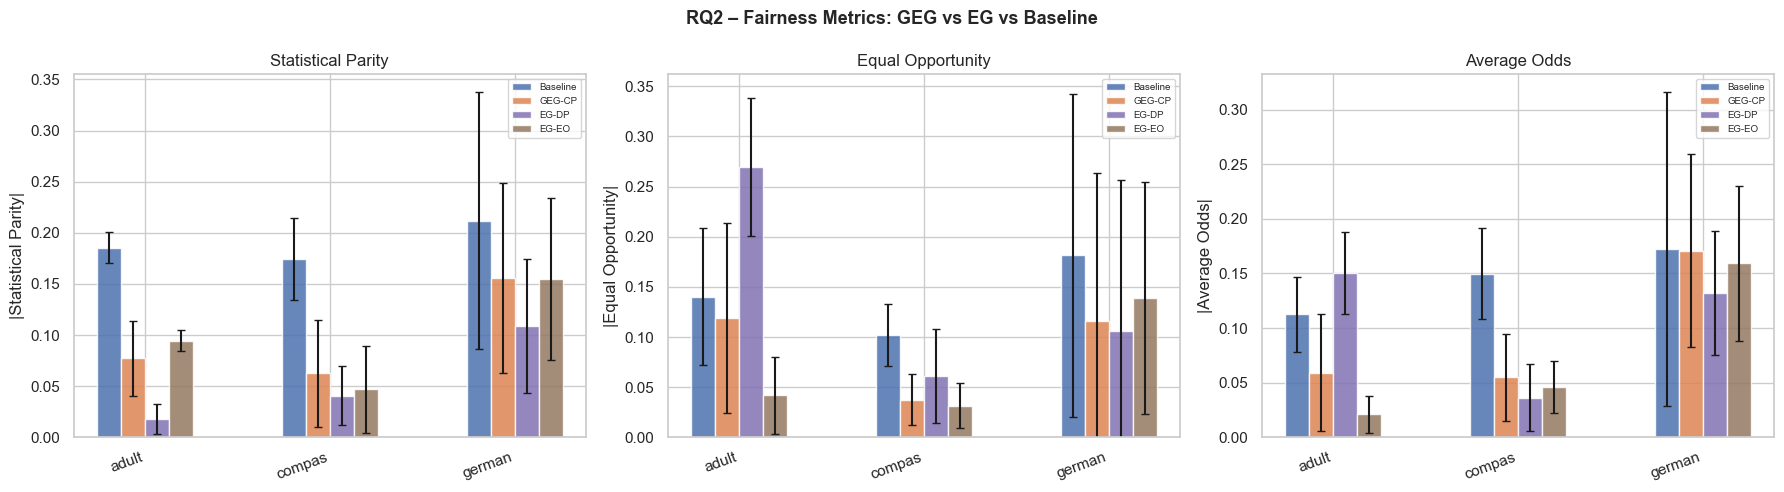

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, FAIRNESS_METRICS):
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    x = np.arange(len(DATASETS))
    n_methods = len(METHODS_ORDER)
    width = 0.13
    offsets = np.linspace(-(n_methods - 1) / 2 * width, (n_methods - 1) / 2 * width, n_methods)

    for i, method in enumerate(METHODS_ORDER):
        sub = (fairness_summary[fairness_summary["method"] == method]
               .set_index("dataset").reindex(DATASETS))
        ax.bar(x + offsets[i], sub[mean_col], width,
               yerr=sub[std_col], label=method,
               color=PALETTE[method], capsize=3, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS, rotation=20, ha="right")
    ax.set_ylabel(f"|{METRIC_LABELS[metric]}|")
    ax.set_title(METRIC_LABELS[metric])
    ax.legend(fontsize=7)
    ax.set_ylim(bottom=0)

fig.suptitle("RQ2 – Fairness Metrics: GEG vs EG vs Baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMGS / "rq2_fairness_bar.pdf", bbox_inches="tight")
plt.show()

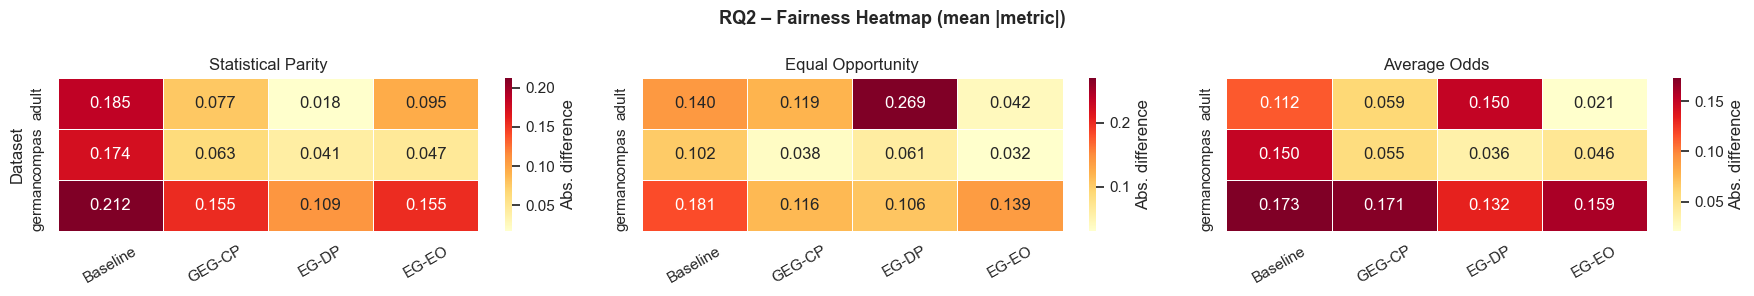

In [12]:
# Heatmap: mean |fairness| per dataset × method
pivot_sp = fairness_summary.pivot(index="dataset", columns="method", values="statistical_parity_mean")
pivot_eo = fairness_summary.pivot(index="dataset", columns="method", values="equal_opportunity_mean")
pivot_ao = fairness_summary.pivot(index="dataset", columns="method", values="average_odds_mean")

fig, axes = plt.subplots(1, 3, figsize=(18, 3))
for ax, pivot, title in zip(axes,
                             [pivot_sp, pivot_eo, pivot_ao],
                             ["Statistical Parity", "Equal Opportunity", "Average Odds"]):
    pivot = pivot.reindex(columns=METHODS_ORDER)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, cbar_kws={"label": "Abs. difference"})
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Dataset" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("RQ2 – Fairness Heatmap (mean |metric|)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMGS / "rq2_fairness_heatmap.pdf", bbox_inches="tight")
plt.show()

## 7. Visualizzazione della Performance per Metodo

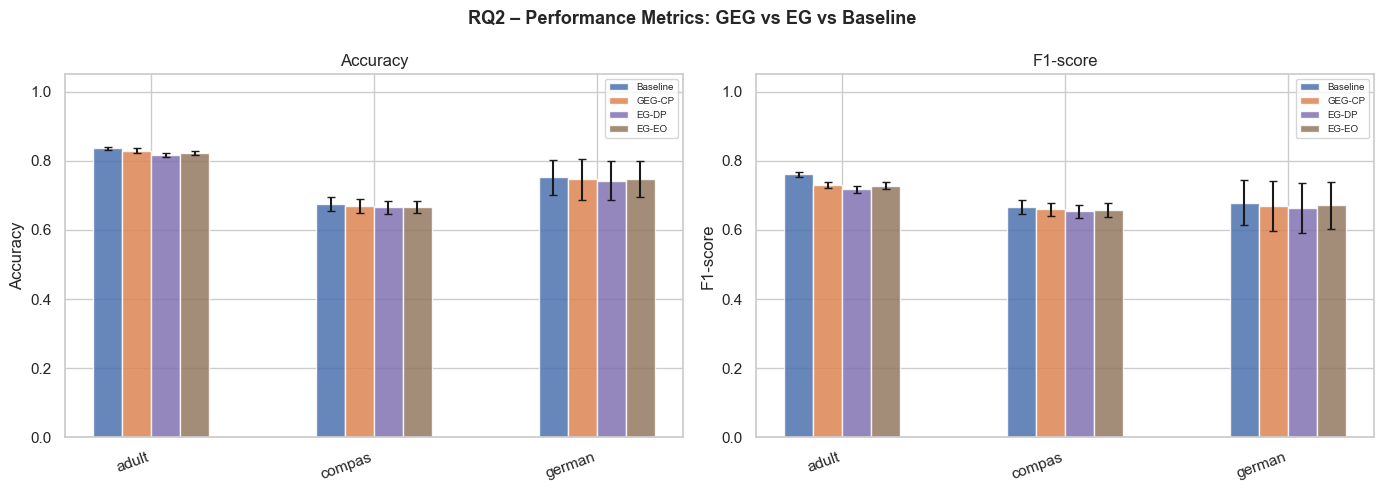

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["accuracy", "f1_score"]):
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    x = np.arange(len(DATASETS))
    n_methods = len(METHODS_ORDER)
    width = 0.13
    offsets = np.linspace(-(n_methods - 1) / 2 * width, (n_methods - 1) / 2 * width, n_methods)

    for i, method in enumerate(METHODS_ORDER):
        sub = (perf_summary[perf_summary["method"] == method]
               .set_index("dataset").reindex(DATASETS))
        ax.bar(x + offsets[i], sub[mean_col], width,
               yerr=sub[std_col], label=method,
               color=PALETTE[method], capsize=3, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS, rotation=20, ha="right")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(METRIC_LABELS[metric])
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.05)

fig.suptitle("RQ2 – Performance Metrics: GEG vs EG vs Baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMGS / "rq2_performance_bar.pdf", bbox_inches="tight")
plt.show()

## 8. Analisi del Trade-off Fairness–Performance

$$T(\alpha) = \alpha \cdot \text{F1} + (1 - \alpha) \cdot (1 - \text{Fair})$$

dove $\text{Fair} = \frac{|SP| + |EO| + |AO|}{3}$. $\alpha \in [0,1]$ bilancia performance e fairness.  
I punti colorati e le linee tratteggiate verticali indicano i valori di $\alpha$ dove le varianti GEG e EG incrociano il Baseline.

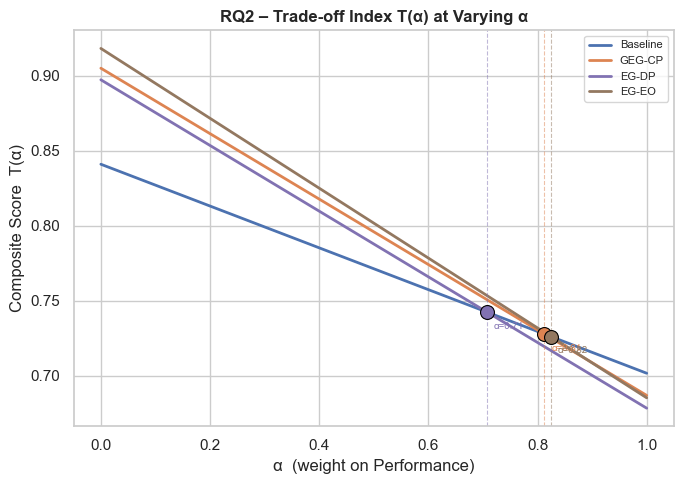


Global means:
   method  accuracy  f1_score  fair_mean
Baseline    0.7543    0.7016     0.1589
  GEG-CP    0.7482    0.6868     0.0948
   EG-DP    0.7411    0.6783     0.1025
   EG-EO    0.7456    0.6852     0.0816


In [14]:
global_means = (
    df_all.groupby("method")[FAIRNESS_METRICS + ["accuracy", "f1_score"]]
    .mean()
    .reset_index()
)
global_means["fair_mean"] = global_means[FAIRNESS_METRICS].mean(axis=1)
global_means["method"] = pd.Categorical(
    global_means["method"], categories=METHODS_ORDER, ordered=True
)
global_means = global_means.sort_values("method")

alphas = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(7, 5))

method_scores = {}
for _, row in global_means.iterrows():
    perf = row["f1_score"]
    fair = row["fair_mean"]
    scores = alphas * perf + (1 - alphas) * (1 - fair)
    method_scores[row["method"]] = (perf, fair)
    ax.plot(alphas, scores, label=row["method"], color=PALETTE[row["method"]], lw=2)

# Mark intersections: Baseline crosses each other method
base_perf, base_fair = method_scores["Baseline"]
for method in [m for m in METHODS_ORDER if m != "Baseline"]:
    if method not in method_scores:
        continue
    m_perf, m_fair = method_scores[method]
    denom = (base_perf - m_perf) + (base_fair - m_fair)
    if abs(denom) < 1e-12:
        continue
    alpha_star = (base_fair - m_fair) / denom
    if 0 <= alpha_star <= 1:
        score_star = alpha_star * base_perf + (1 - alpha_star) * (1 - base_fair)
        ax.scatter(alpha_star, score_star, color=PALETTE[method],
                   s=100, zorder=6, edgecolors="black", linewidths=0.8)
        ax.axvline(alpha_star, color=PALETTE[method], lw=0.8, linestyle="--", alpha=0.5)
        ax.annotate(f"α={alpha_star:.2f}", (alpha_star, score_star),
                    xytext=(5, -12), textcoords="offset points",
                    fontsize=7, color=PALETTE[method])

ax.set_xlabel("α  (weight on Performance)")
ax.set_ylabel("Composite Score  T(α)")
ax.set_title("RQ2 – Trade-off Index T(α) at Varying α", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(IMGS / "rq2_tradeoff_alpha.pdf", bbox_inches="tight")
plt.show()

print("\nGlobal means:\n",
      global_means[["method", "accuracy", "f1_score", "fair_mean"]].to_string(index=False))

## 9. Grafico di Pareto per Dataset

Ogni subplot mostra i 6 metodi nello spazio fairness–F1 per un singolo dataset.  
I punti Pareto-efficienti (minore fairness violation, maggiore F1) sono evidenziati con una stella.

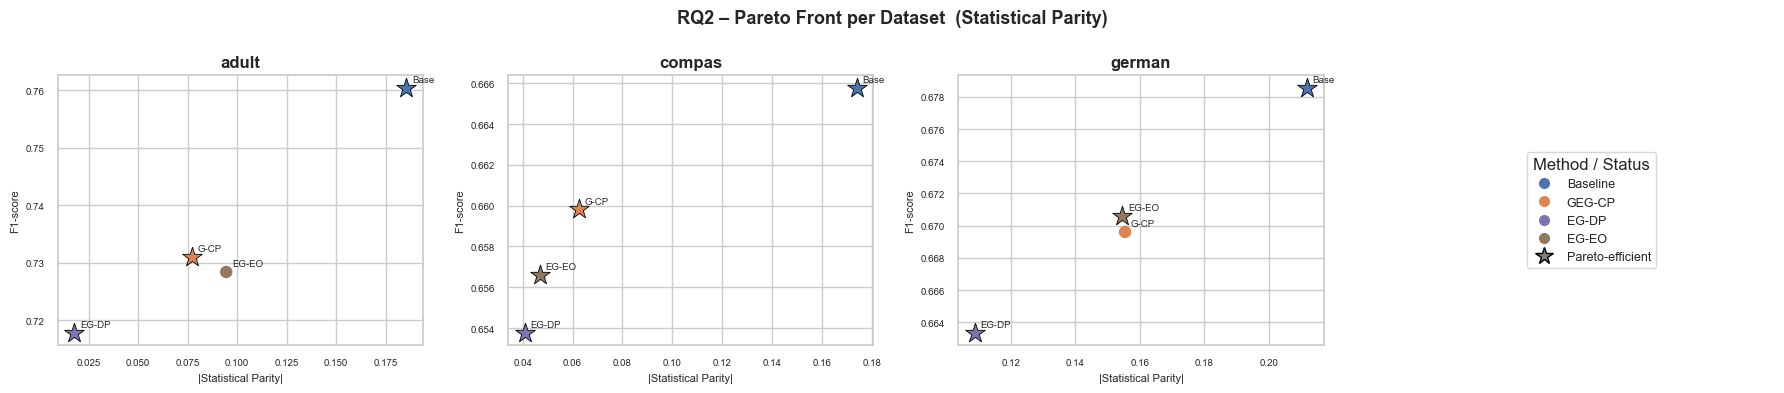

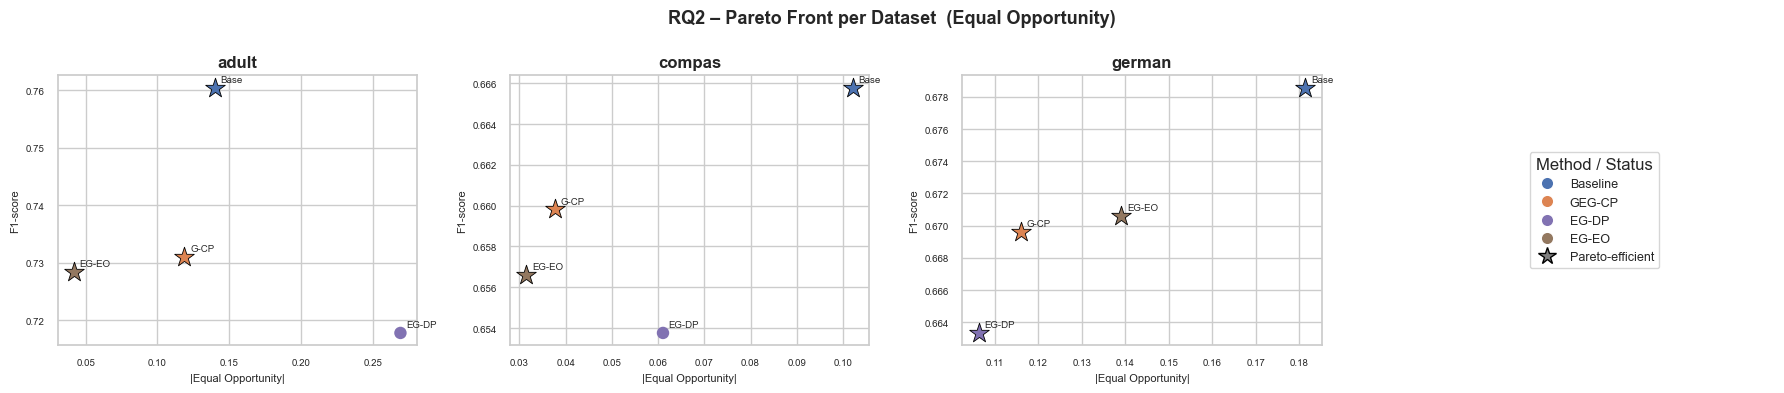

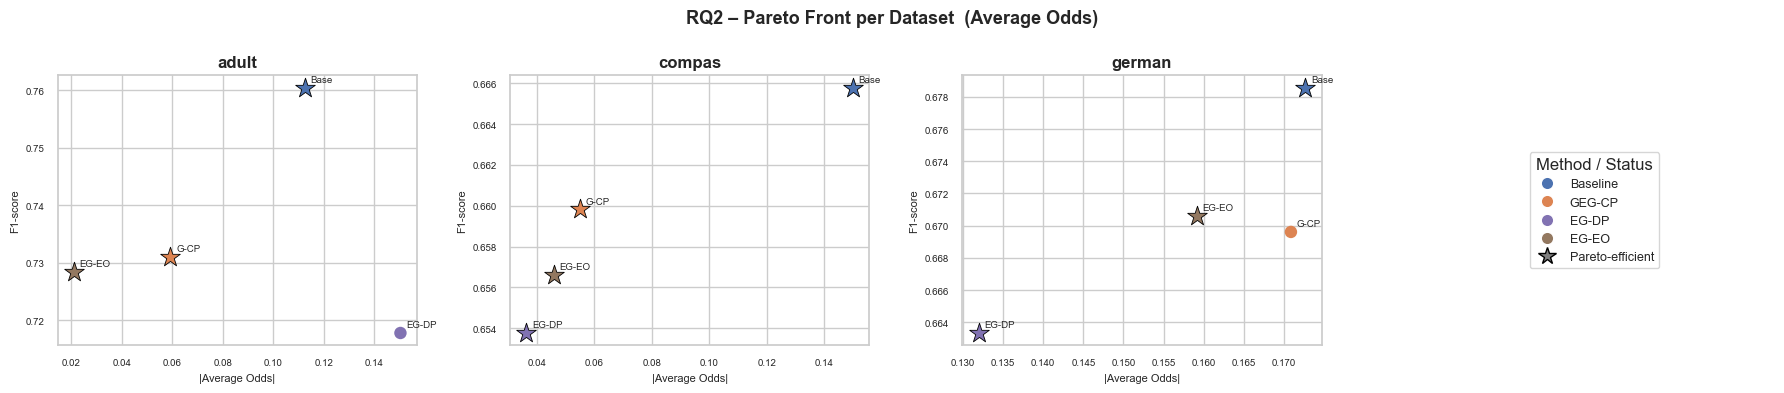

In [15]:
def is_pareto_efficient(costs):
    """Boolean mask: True = Pareto-efficient (minimise col0, maximise col1)."""
    n = len(costs)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if costs[j, 0] <= costs[i, 0] and costs[j, 1] >= costs[i, 1]:
                if costs[j, 0] < costs[i, 0] or costs[j, 1] > costs[i, 1]:
                    dominated[i] = True
                    break
    return ~dominated


scatter_data = combined[["dataset", "method",
                          "statistical_parity_mean", "equal_opportunity_mean",
                          "average_odds_mean", "f1_score_mean"]].copy()
scatter_data["fair_mean"] = scatter_data[["statistical_parity_mean",
                                          "equal_opportunity_mean",
                                          "average_odds_mean"]].mean(axis=1)

for fairness_col, fair_label, fname in [
    ("statistical_parity_mean", "Statistical Parity", "rq2_pareto_sp_per_dataset.pdf"),
    ("equal_opportunity_mean",  "Equal Opportunity",  "rq2_pareto_eo_per_dataset.pdf"),
    ("average_odds_mean",       "Average Odds",       "rq2_pareto_ao_per_dataset.pdf"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for ax_idx, ds in enumerate(DATASETS):
        ax = axes[ax_idx]
        ds_data = (scatter_data[scatter_data["dataset"] == ds]
                   .set_index("method").reindex(METHODS_ORDER).reset_index())

        pts = ds_data[[fairness_col, "f1_score_mean"]].values
        pareto_mask = is_pareto_efficient(pts)

        for i, row in ds_data.iterrows():
            mx = row[fairness_col]
            my = row["f1_score_mean"]
            method = row["method"]
            is_p = pareto_mask[i]
            ax.scatter(mx, my,
                       color=PALETTE[method],
                       s=220 if is_p else 80,
                       marker="*" if is_p else "o",
                       edgecolors="black" if is_p else "none",
                       linewidths=0.6, zorder=5 if is_p else 3,
                       label=method)
            ax.annotate(method.replace("GEG-", "G-").replace("Baseline", "Base"),
                        (mx, my), fontsize=7,
                        xytext=(4, 4), textcoords="offset points")

        ax.set_title(ds, fontweight="bold")
        ax.set_xlabel(f"|{fair_label}|", fontsize=8)
        ax.set_ylabel("F1-score", fontsize=8)
        ax.tick_params(labelsize=7)

    # Legend in the 4th (spare) panel
    legend_ax = axes[-1]
    legend_ax.axis("off")
    method_handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=PALETTE[m], markersize=9, label=m)
        for m in METHODS_ORDER
    ]
    pareto_handle = plt.Line2D([0], [0], marker="*", color="w",
                               markerfacecolor="grey", markeredgecolor="black",
                               markersize=13, label="Pareto-efficient")
    legend_ax.legend(handles=method_handles + [pareto_handle],
                     loc="center", fontsize=9, frameon=True, title="Method / Status")

    fig.suptitle(f"RQ2 – Pareto Front per Dataset  ({fair_label})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(IMGS / fname, bbox_inches="tight")
    plt.show()